# Programming Exercise 3: Logistic Regression



## Introduction

In this exercise, you will implement logistic regression and apply it to two different datasets.

All the information you need for solving this assignment is in this notebook, and all the code you will be implementing will take place within this notebook.

Before we begin with the exercises, we need to import all libraries required for this programming exercise. Throughout the course, we will be using [`numpy`](http://www.numpy.org/) for all arrays and matrix operations, and [`matplotlib`](https://matplotlib.org/) for plotting.

### Section 1 Logistic Regression

In this part of the exercise, you will build a logistic regression model to predict whether a student gets admitted into a university. Suppose that you are the administrator of a university department and
you want to determine each applicant’s chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant’s scores on two exams and the admissions
decision. Your task is to build a classification model that estimates an applicant’s probability of admission based the scores from those two exams.

The following cell will load the data and corresponding labels:

In [1173]:
import pandas as pd
import numpy as np

In [1174]:
students = pd.read_csv("ex2data1.txt", names=["First_Exam", "Second_Exam", "Admission_Status"])
# type casting from pandas series and pandas dataframe to numpy array
X = np.array(students[["First_Exam", "Second_Exam"]])
y = np.array(students["Admission_Status"])
# size of dataset
number_of_samples = y.size
# size of X matrix, m= rows, n= features
m,n = X.shape
print('size of samples: {}'.format(number_of_samples))

size of samples: 100


In [1175]:
students.head()

,First_Exam,Second_Exam,Admission_Status
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### 1.1 Visualizing the data

Before starting to implement any learning algorithm, it is always good to visualize the data if possible.
please visualize the first dataset using the package `matplotlib`.

In [1176]:
import matplotlib.pyplot as plt

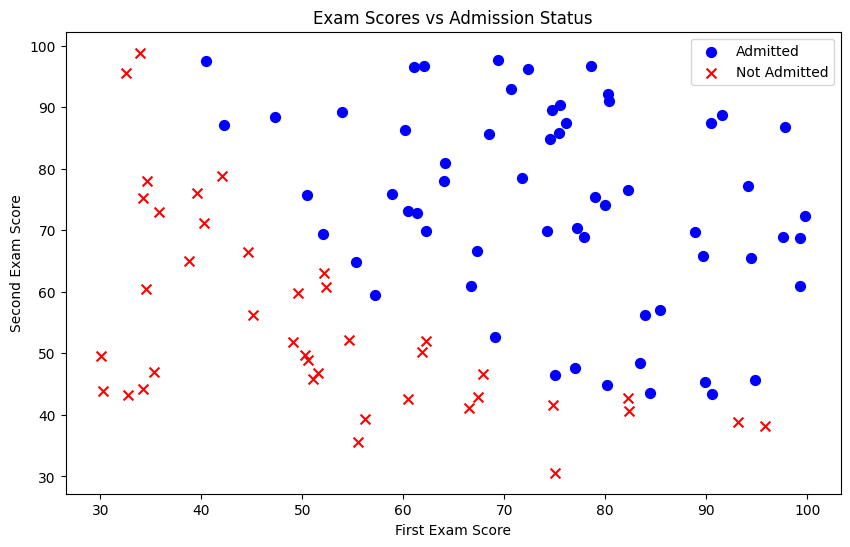

In [1177]:
admitted = students[students["Admission_Status"] == 1]
not_admitted = students[students["Admission_Status"] == 0]

plt.figure(figsize=(10, 6))

# Plot admitted students
plt.scatter(admitted["First_Exam"], admitted["Second_Exam"], s=50, c='b', marker='o', label='Admitted')

# Plot not admitted students
plt.scatter(not_admitted["First_Exam"], not_admitted["Second_Exam"], s=50, c='r', marker='x', label='Not Admitted')

# Adding labels and title
plt.xlabel('First Exam Score')
plt.ylabel('Second Exam Score')
plt.title('Exam Scores vs Admission Status')
plt.legend()

# Show plot
plt.show()

### 1.2 Implementation

#### 1.2.1 Warmup exercise: sigmoid function

Before you start with the actual cost function, recall that the logistic regression hypothesis is defined as:

$$ h_\theta(x) = g(\theta^T x)$$

where function $g$ is the sigmoid function. The sigmoid function is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$

Your first step is to implement this function `sigmoid` so it can be
called by the rest of your program. When you are finished, try testing a few
values by calling `sigmoid(x)` in a new cell. For large positive values of `x`, the sigmoid should be close to 1, while for large negative values, the sigmoid should be close to 0. Evaluating `sigmoid(0)` should give you exactly 0.5. Your code should also work with vectors and matrices. **For a matrix, your function should perform the sigmoid function on every element.**


In [1178]:
def sigmoid(z):
    """
    Compute sigmoid function given the input z.

    Parameters
    ----------
    z : array_like
        The input to the sigmoid function. This can be a 1-D vector
        or a 2-D matrix.

    Returns
    -------
    g : array_like
        The computed sigmoid function. g has the same shape as z, since
        the sigmoid is computed element-wise on z.
    """

    g = 1 / (1 + np.exp(-z))
    return g


In [1179]:
# test sigmoid function
z = 0
g = sigmoid(z)

print("Actual value of sigmoid(0) should be 0.5")
print("Computed value of sigmoid(0) is {sigmoid}".format(sigmoid= g))

Actual value of sigmoid(0) should be 0.5
Computed value of sigmoid(0) is 0.5


#### 1.2.2 Cost function and gradient

Now you will implement the cost function and gradient for logistic regression. Before proceeding we add the intercept term to X.


In [1180]:
# add intercept term to martix X
X = np.concatenate([np.ones((len(X), 1)), X], axis= 1)
### make  theta_0 as the bias term
theta = np.zeros(n+1)

Note that the parameter $\theta_0$ represents the bias term in the model's weights.
Now, complete the code for the function `cost_function` to return the cost value and define `gradient_descent` to reteun gradient. Recall that the cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

and the gradient of the cost is a vector of the same length as $\theta$ where the $j^{th}$
element (for $j = 0, 1, \cdots , n$) is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Note that while this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $h_\theta(x)$.

In [1181]:
def cost_function(theta, X, y):
    m = y.size  # number of training examples

    # Hypothesis function
    h = sigmoid(np.dot(X, theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    # Cost function
    J = (1 / m) * (np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)))

    return J

In [1182]:
def gradient_descent(theta, X, y):
    m = y.size # number of training examples

    # Hypothesis function
    h = sigmoid(np.dot(X, theta))
    # Compute gradient
    grad = (1 / m) * np.dot(X.T, (h - y))
    
    return grad

In [1183]:
### check the gradient and with theta=np.zeros(n+1)

In [1184]:
initial_theta = np.zeros(n + 1)
grad = gradient_descent(initial_theta, X, y)
cost = cost_function(initial_theta,X,y)
print("Shape of cost value is: {}".format(cost))
print("Shape of grad is: {}".format(grad.shape))

Shape of cost value is: 0.6931471805599453
Shape of grad is: (3,)


### calculate the optimal theta using stochastic gradient deacent




In [1185]:
def train_using_sgd(theta, X, y, learning_rate=0.0001, epochs=100000):
    """
    Perform stochastic gradient descent to train the logistic regression model.
    """
    
    m = y.size

    for epoch in range(epochs):
        for i in range(m):
            xi = X[i, :]
            yi = y[i]
            hi = sigmoid(np.dot(xi, theta))
            gradient = (hi - yi) * xi
            theta = theta - learning_rate * gradient

    return theta

# Example usage:
# Assuming you have X, y, and theta initialized appropriately
# Train the logistic regression model using stochastic gradient descent
theta_optimized = train_using_sgd(theta, X, y)


In [1186]:
print("Optimized theta is: {}".format(theta_optimized))
optimaize_cost = cost_function(theta_optimized,X,y)

print("Optimized Cost value is: {:.4f}".format(optimaize_cost))

Optimized theta is: [-16.04621243   0.13947329   0.13600827]
Optimized Cost value is: 0.2562


### Plot the decision boundary obtained from the logistic regression model trained using gradient descent

---



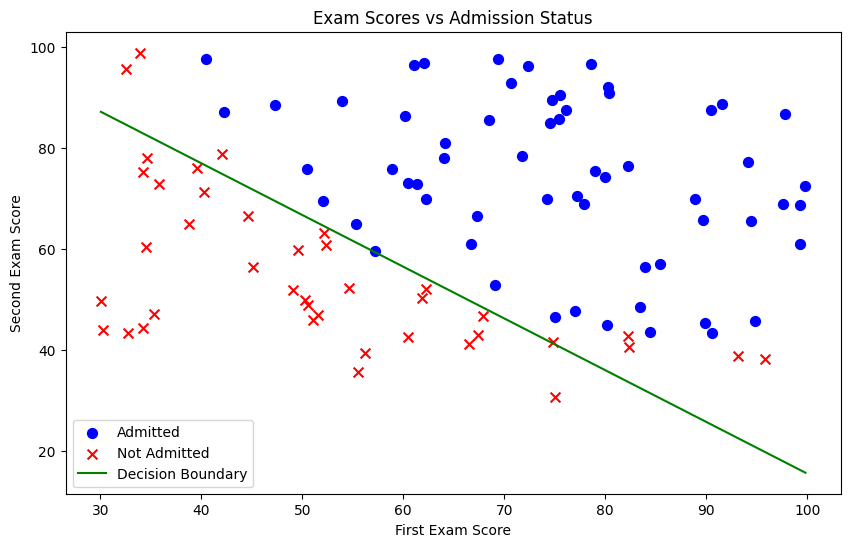

In [1187]:

plt.figure(figsize=(10, 6))

# Plot admitted students
plt.scatter(admitted["First_Exam"], admitted["Second_Exam"], s=50, c='b', marker='o', label='Admitted')

# Plot not admitted students
plt.scatter(not_admitted["First_Exam"], not_admitted["Second_Exam"], s=50, c='r', marker='x', label='Not Admitted')

# Calculate and plot the decision boundary
x_values = np.array([np.min(students["First_Exam"]), np.max(students["First_Exam"])])
y_values = -(theta_optimized[0] + theta_optimized[1] * x_values) / theta_optimized[2]
plt.plot(x_values, y_values, color='green', label='Decision Boundary')

# Adding labels and title
plt.xlabel('First Exam Score')
plt.ylabel('Second Exam Score')
plt.title('Exam Scores vs Admission Status')
plt.legend()

# Show plot
plt.show()

#### 1.2.4 Evaluating logistic regression

After learning the parameters, you can use the model to predict whether a particular student will be admitted. For a student with an Exam 1 score of 53 and an Exam 2 score of 94, print the admission
probability.

In [1188]:
def predict(theta, X):

    # Calculate the hypothesis using the sigmoid function
    z = np.dot(X, theta)
    probabilities  = sigmoid(z)
    return probabilities



In [1189]:
def accuracy(y_pred, y):
    """
    check prediction accuracy with comparison between predict and actual value
    if two parameter(predicted and actual value) are equal diff will be 0 and
    otherwise will be 1. count of nonzero devided by len of diff is errors. 1 minus
    error is our prediction accuracy

    Parameters
    ----------
    y_pred : array_like
        Predicted values that output of predict function.

    y : array_like
        Actual value of data, (Labels)

    Returns
    -------
    number : float
        model accuracy percentage
    """

    y_pred_classified = (y_pred >= 0.5).astype(int)
    
    # Compare predicted labels with actual labels
    correct_predictions = (y_pred_classified == y).astype(int)
    
    # Calculate the accuracy
    accuracy = np.mean(correct_predictions) * 100  # Convert to percentage
    
    return accuracy


After you have completed the code in `predict`, we proceed to report the training accuracy of your classifier by computing the percentage of examples it got correct.

The admission probability for a student with scores 45 and 85 is 0.8570239226313543


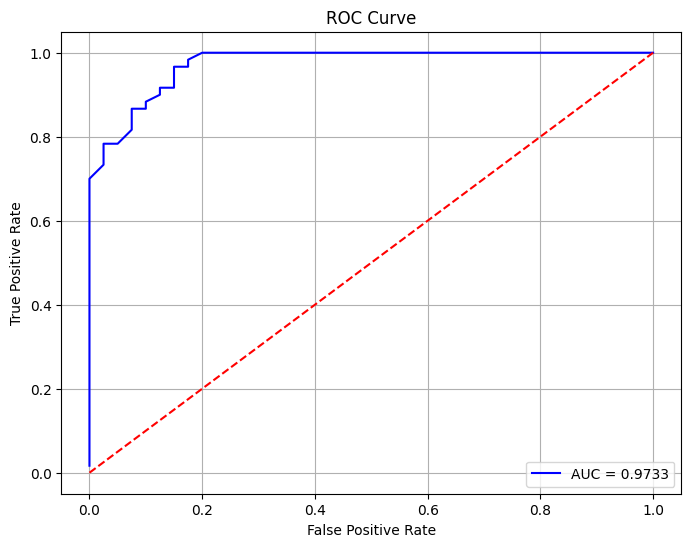

Training Accuracy: 92.00%
AUC: 0.9733


In [1190]:
# Assuming theta_optimized, X, and y are properly defined
student_features = np.array([1, 45, 85])
admission_probability = predict(theta_optimized, student_features)
print(f"The admission probability for a student with scores 45 and 85 is {admission_probability}")

y_pred_prob = predict(theta_optimized, X)

# Calculate accuracy
accuracy = np.mean((y_pred_prob >= 0.5) == y) * 100

# Set number of thresholds for the ROC curve
num_thresholds = 100
min_prob, max_prob = np.min(y_pred_prob), np.max(y_pred_prob)
thresholds = np.linspace(min_prob, max_prob, num_thresholds)

# Calculate TPR and FPR for each threshold
tpr = []
fpr = []
for thresh in thresholds:
    predictions = y_pred_prob >= thresh
    TP = np.sum((predictions == 1) & (y == 1))
    FN = np.sum((predictions == 0) & (y == 1))
    FP = np.sum((predictions == 1) & (y == 0))
    TN = np.sum((predictions == 0) & (y == 0))

    TPR = TP / (TP + FN) if TP + FN else 0
    FPR = FP / (FP + TN) if FP + TN else 0

    tpr.append(TPR)
    fpr.append(FPR)

# Calculate AUC using the custom trapezoidal rule function
roc_auc = 0.0
for i in range(1, len(fpr)):
    delta_x = fpr[i] - fpr[i-1]
    avg_y = (tpr[i] + tpr[i-1]) / 2
    roc_auc -= delta_x * avg_y


# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linestyle='-', color='blue', label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

print(f"Training Accuracy: {accuracy:.2f}%")
print(f"AUC: {roc_auc:.4f}")

plot the AUC and the ROC curve on your model



```
# This is formatted as code
```

## Section 2 Regularized logistic regression

In this part of the exercise, you will implement regularized logistic regression to predict whether microchips from a fabrication plant passes quality assurance (QA). During QA, each microchip goes through various tests to ensure it is functioning correctly.
Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests. From these two tests, you would like to determine whether the microchips should be accepted or rejected. To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.

First, we load the data from a CSV file:

In [1191]:
microchips= pd.read_csv("ex2data2.txt", names=["First_Test", "Second_Test", "Status"])
# type casting from pandas series and pandas dataframe to numpy array
X = np.array(microchips[["First_Test", "Second_Test"]])
y = np.array(microchips["Status"])
# size of dataset
number_of_samples = y.size
# size of X matrix, m= rows, n= features
m,n = X.shape
print('size of samples: {}'.format(number_of_samples))

size of samples: 118


### 2.1 Visualize the data

Similar to the previous parts of this exercise, where the axes are the two test scores, and the positive (y = 1, accepted) and negative (y = 0, rejected) examples are shown with
different markers.

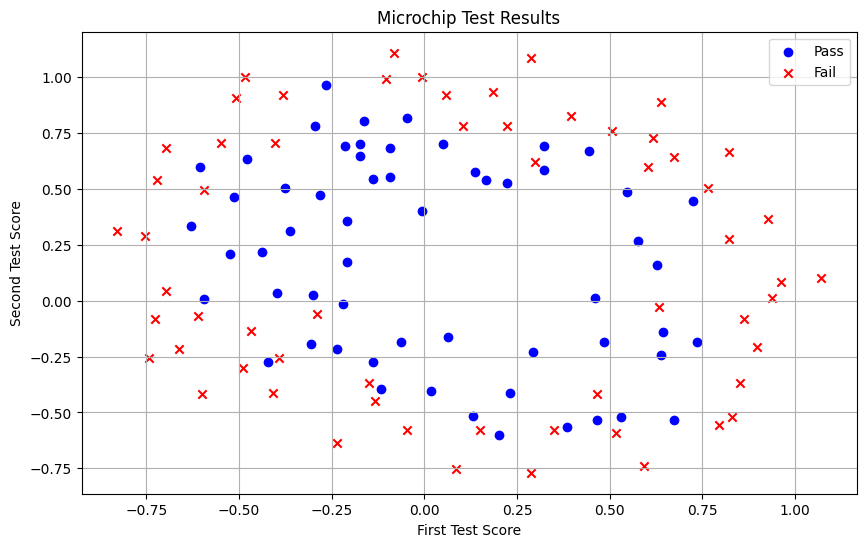

In [1192]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='b', label='Pass', marker='o')
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='r', label='Fail', marker='x')
plt.xlabel('First Test Score')
plt.ylabel('Second Test Score')
plt.title('Microchip Test Results')
plt.legend()
plt.grid(True)
plt.show()



The above figure shows that our dataset cannot be separated into positive and negative examples by a straight-line through the plot. Therefore, a straight-forward application of logistic regression will not perform well on this dataset since logistic regression will only be able to find a linear decision boundary.

### 2.2 Feature mapping

One way to fit the data better is to create more features from each data point. In the function `map_feature`, we will map the features into all polynomial terms of $x_1$ and $x_2$ up to the sixth power.

$$ text{map_feature}(x) = \begin{bmatrix} 1 & x_1 & x_2 & x_1^2 & x_1 x_2 & x_2^2 & x_1^3 & \dots & x_1 x_2^5 & x_2^6 \end{bmatrix}^T $$

As a result of this mapping, our vector of two features (the scores on two QA tests) has been transformed into a 28-dimensional vector. A logistic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will appear nonlinear when drawn in our 2-dimensional plot.
While the feature mapping allows us to build a more expressive classifier, it also more susceptible to overfitting. In the next parts of the exercise, you will implement regularized logistic regression to fit the data and also see for yourself how regularization can help combat the overfitting problem.


In [1193]:
### make the map feature function

In [1194]:
def map_feature(X1, X2, degree=6):

    X1 = np.asarray(X1).reshape(-1, 1)  # Ensure X1 is a column vector
    X2 = np.asarray(X2).reshape(-1, 1)  # Ensure X2 is a column vector

    if X1.shape != X2.shape:
        raise ValueError("X1 and X2 must be the same size")

    array_like = np.ones((X1.shape[0], 1))
    for i in range(1, degree + 1):
        for j in range(i + 1):
            new_feature = (X1 ** (i - j)) * (X2 ** j)
            array_like = np.hstack((array_like, new_feature))

    return array_like



In [1195]:
X = map_feature(X[:,0], X[:,1])


### 2.3 Cost function and gradient
Note that the parameter $\theta_0$ represents the bias term in the model's weights.
Now you will implement code to compute the cost function and gradient for regularized logistic regression. Complete the code for the function `cost_function_gradient_descent_regularized` below to return the cost and gradient.

Recall that the regularized cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)}\log \left( h_\theta \left(x^{(i)} \right) \right) - \left( 1 - y^{(i)} \right) \log \left( 1 - h_\theta \left( x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Note that you should not regularize the parameters $\theta_0$. The gradient of the cost function is a vector where the $j^{th}$ element is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \qquad \text{for } j =0 $$

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \left( \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \right) + \frac{\lambda}{m}\theta_j \qquad \text{for } j \ge 1 $$

In [1196]:
def cost_function_gradient_descent_regularized(theta, X, y, lambda_):

    m = y.size  # number of training examples
    h = sigmoid(X.dot(theta))
    
    # Regularized cost function
    J = -(1/m) * (np.dot(y, np.log(h)) + np.dot((1 - y), np.log(1 - h))) \
        + (lambda_ / (2 * m)) * np.sum(np.square(theta[1:]))
    
    # Gradient calculation
    grad = np.zeros(theta.shape)
    grad[0] = (1 / m) * np.dot(X[:, 0], (h - y))  # Gradient for theta_0
    for j in range(1, len(theta)):
        grad[j] = (1 / m) * np.dot(X[:, j], (h - y)) + (lambda_ / m) * theta[j]  
    
    return J, grad


#### 2.3.1 Learning parameters using momentum

Similar to the previous parts, you will optimize the Regularized logistic regression using the momentum algorithm optimize the model with $\lambda = 1$, $\lambda = 0$

In [1197]:
def train_using_momentum(theta, X, y, learning_rate,beta,lmbda, epochs=100):
    m = len(y)  # number of training examples
    v = np.zeros(theta.shape)  # initialize momentum term

    for epoch in range(epochs):
        J, grad = cost_function_gradient_descent_regularized(theta, X, y, lmbda)

        # Update the momentum term
        v = beta * v + (1 - beta) * grad
        
        # Update parameters
        theta -= learning_rate * v

    return theta

In [1198]:
# initialize parameters
theta = np.zeros(28)  # Adjust this depending on the number of features in X
learning_rate = 0.01  # Define a suitable learning rate
beta = 0.9  # Momentum hyper-parameter
lambda_ = 1  # Regularization strength

theta_optimized = train_using_momentum(theta, X, y, learning_rate, beta, lambda_, epochs=100000)



In [1199]:
# Compute accuracy on our training set
# Calculate the hypothesis using the sigmoid function
z = np.dot(X, theta)
probabilities  = sigmoid(z)
model_predicted = (probabilities >= 0.5).astype(int)

print("Train Accuracy: {:.1f}".format((np.mean(model_predicted == y) * 100)))
print("Expected accuracy (with lambda = 1): 83.1 % (approx)\n")

Train Accuracy: 83.1
Expected accuracy (with lambda = 1): 83.1 % (approx)



### plot the decision boundery for $\lambda =1$




In [1200]:
pos = y == 1
neg = y == 0


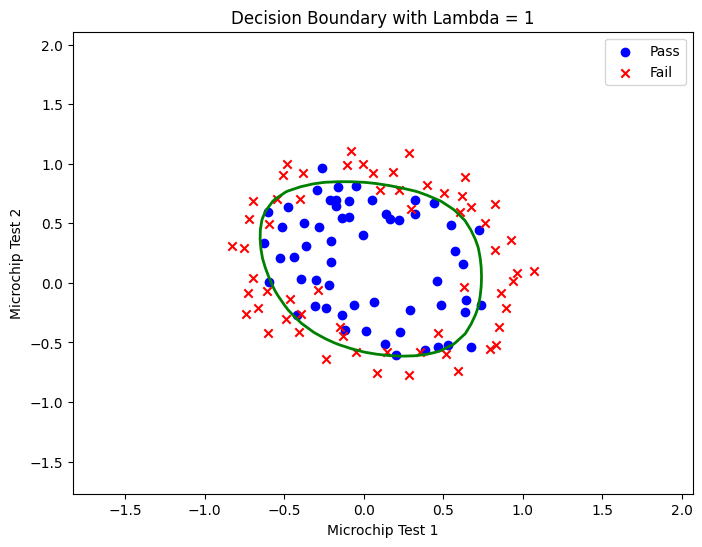

In [1201]:
pos = y == 1
neg = y == 0

# Set up the grid for plotting.
x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
y_min, y_max = X[:, 2].min() - 1, X[:, 2].max() + 1
u = np.linspace(x_min, x_max, 50)
v = np.linspace(y_min, y_max, 50)
z = np.zeros((len(u), len(v)))

# Compute z values over the grid by mapping features and computing predictions using the trained theta
for i in range(len(u)):
    for j in range(len(v)):
        sample = map_feature(np.array([u[i]]), np.array([v[j]]))
        z_val = np.dot(sample, theta_optimized)
        if isinstance(z_val, np.ndarray) and z_val.size == 1:
            z_val = z_val.item()  # Convert array to scalar explicitly if needed
        z[i, j] = z_val

z = z.T  # Important to transpose z before plotting

# Plot
plt.figure(figsize=(8, 6))
plt.contour(u, v, z, levels=[0], linewidths=2, colors='green')
plt.scatter(X[pos, 1], X[pos, 2], c='b', label='Pass', marker='o')
plt.scatter(X[neg, 1], X[neg, 2], c='r', label='Fail', marker='x')
plt.title(f"Decision Boundary with Lambda = {1}")
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.legend()
plt.show()

### plot the decision boundery for $\lambda=0$




In [1202]:
lambda_ = 1  # Regularization strength
theta_optimized = train_using_momentum(theta, X, y, learning_rate, beta, lambda_, epochs=100000)
pos = y == 1
neg = y == 0



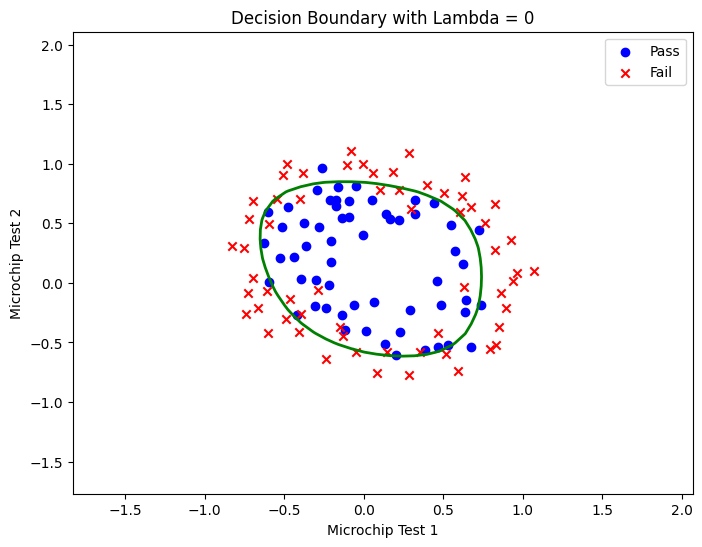

In [1203]:
pos = y == 1
neg = y == 0

# Set up the grid for plotting.
x_min, x_max = X[:, 1].min() - 1, X[:, 1].max() + 1
y_min, y_max = X[:, 2].min() - 1, X[:, 2].max() + 1
u = np.linspace(x_min, x_max, 50)
v = np.linspace(y_min, y_max, 50)
z = np.zeros((len(u), len(v)))

# Compute z values over the grid by mapping features and computing predictions using the trained theta
for i in range(len(u)):
    for j in range(len(v)):
        sample = map_feature(np.array([u[i]]), np.array([v[j]]))
        z_val = np.dot(sample, theta_optimized)
        if isinstance(z_val, np.ndarray) and z_val.size == 1:
            z_val = z_val.item()  # Convert array to scalar explicitly if needed
        z[i, j] = z_val

z = z.T  # Important to transpose z before plotting

# Plot
plt.figure(figsize=(8, 6))
plt.contour(u, v, z, levels=[0], linewidths=2, colors='green')
plt.scatter(X[pos, 1], X[pos, 2], c='b', label='Pass', marker='o')
plt.scatter(X[neg, 1], X[neg, 2], c='r', label='Fail', marker='x')
plt.title(f"Decision Boundary with Lambda = {0}")
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.legend()
plt.show()